# 4종 모델 비교 — P1

지금까지 만든 네 모델을 **같은 기간, 같은 데이터**로 비교한다.

| 모델 | 1행의 정체 | 피처 | 비고 |
|---|---|---|---|
| **Tick** | 틱 1개 | 14 | 기존 `train_pump.ipynb` 방식 (비교 기준선) |
| **Cycle v2** | 사이클 1회 | 31 | 정규화 없음 |
| **Cycle v3** | 사이클 1회 | 23 | 중복 제거 + 표준화 잔차 |
| **Shot** | 사출 1회 | 10 | 딥의 모양에 집중 |

**재구성오차(MSE)는 비교하지 않는다.** 단위(틱/사이클/사출)도 피처 수도 달라서
숫자 자체로는 우열을 가릴 수 없다. 대신 이렇게 비교한다.

1. **무엇을 범인으로 지목하는가** — 라벨이 없어도 "SV 변경은 고장이 아니다"는 판정이 가능
2. **경보량** — 하루 몇 건이면 현장에서 볼 수 있는가
3. **일별 추세** — 서서히 진행되는 열화를 잡는가
4. **검출 겹침** — 서로 대체 가능한가, 보완적인가
5. **학습 건전성** — 과적합 없이 수렴했는가

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd, torch, joblib
import torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import (extract_cycle_features, PUMP_MAP,
                                     DAILY_EXCLUDE_START, DAILY_EXCLUDE_END)
from Cycle_Normalizer import ResidualNormalizer, NORMALIZE_SPECS, SUFFIX
from Cycle_AE import CycleAutoencoder
from Shot_Feature_Extractor import (extract_shot_features, SHOT_FEATURE_COLS,
                                    SHOT_NORMALIZE_SPECS)
from Shot_AE_Model import ShotAutoencoder
from Pump_AE import PumpAutoencoder
import Anomaly_Viewer as V

ENV_PATH = os.path.join(ROOT_DIR, ".env")
PUMP_ID = "P1"
info = PUMP_MAP[PUMP_ID]
HEAD, ROBOT, SLOT, TANK = info["head"], info["robot"], info["slot"], info["tank"]

TRAIN_START, TRAIN_END = "2026-09-10T07:00:00Z", "2026-09-18T07:00:00Z"
VALID_START, VALID_END = "2026-09-18T07:00:00Z", "2026-09-19T07:00:00Z"
TEST_START,  TEST_END  = "2026-09-20T19:00:00Z", "2026-09-23T18:00:00Z"

CACHE = V.cache_path(f"compare4_{PUMP_ID}.pkl")
FORCE_REFRESH = False
print(f"{PUMP_ID}: 헤드 {HEAD}, 로봇 {ROBOT}, 탱크 {TANK}, 사출 Shot_Injection_{HEAD}_P{SLOT}")

P1: 헤드 HD1, 로봇 RB1, 탱크 P1, 사출 Shot_Injection_HD1_P1


## 1. 데이터 추출 (세 기간 한 번씩)

In [2]:
TAGS = [f"Pump_BuildUp_{PUMP_ID}", f"g_s_SV_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
        f"Scale_Out___PT_{PUMP_ID}", f"Ana_Out_{PUMP_ID}", f"TK_Temp_PV_{TANK}",
        f"Hz_Out_{PUMP_ID}", f"Shot_Injection_{HEAD}_P{SLOT}", f"{ROBOT}_Robot_Num",
        "AL_Line_Bit"] + [f"{HEAD}_FOAMING_SHOT{k}" for k in range(1, 7)]

if (not FORCE_REFRESH) and os.path.exists(CACHE):
    with open(CACHE, "rb") as f:
        RAW = pickle.load(f)
    print(f"캐시 사용: {CACHE}")
else:
    ex = LogExtractor(env_path=ENV_PATH)
    RAW = {}
    for name, a, b in [("train", TRAIN_START, TRAIN_END),
                       ("valid", VALID_START, VALID_END),
                       ("test",  TEST_START,  TEST_END)]:
        RAW[name] = ex.get_data(start_time=a, end_time=b, target_tags=TAGS)
    with open(CACHE, "wb") as f:
        pickle.dump(RAW, f)
    print(f"캐시 저장: {CACHE}")

for k, v in RAW.items():
    print(f"  {k:6s} {len(v):>9,}행")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-18T07:00:00+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

39428행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

35983행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

37083행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

38257행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

38990행
📦 [Chunk] 2026-09-23T06:50:00Z ~ 2026-09-23T12:50:00Z ... 

39402행
📦 [Chunk] 2026-09-23T12:50:00Z ~ 2026-09-23T18:00:00Z ... 

31302행


✅ 통합 완료 — 445732행 × 17컬럼
🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P1            Scale_Max___TT_P1=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.


캐시 저장: C:\Users\taetk\Documents\KTA_Train\parkkt\cache\compare4_P1.pkl
  train  1,177,263행
  valid    148,637행
  test     445,732행


## 2. 네 모델 점수 매기기

In [3]:
SCORES = {}      # 모델명 -> DataFrame(Time, err)
INFO = {}        # 모델명 -> dict(threshold, n_feat, unit, culprits, loss)


def recon(model, X):
    model.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X); pf = ((t - model(t)) ** 2).numpy()
    return pf.mean(axis=1), pf


def register(name, unit, n_feat, times, err_tr, err_te, pf_te, cols, loss=None):
    th = float(np.percentile(err_tr, 99))
    am = err_te > th
    ctr = (pd.Series((pf_te / pf_te.sum(axis=1, keepdims=True) * 100)[am].mean(axis=0),
                     index=cols).sort_values(ascending=False) if am.sum() else pd.Series(dtype=float))
    SCORES[name] = pd.DataFrame({"Time": pd.to_datetime(times), "err": err_te})
    INFO[name] = {"unit": unit, "n_feat": n_feat, "threshold": th,
                  "n_test": len(err_te), "n_anom": int(am.sum()),
                  "rate": am.mean() * 100, "culprits": ctr, "loss": loss}
    print(f"[{name}] {unit} {len(err_te):,}건 | 임계치 {th:.4f} | "
          f"이상 {int(am.sum()):,}건 ({am.mean()*100:.2f}%)")
    if len(ctr):
        print("   범인: " + ", ".join(f"{k} {v:.0f}%" for k, v in ctr.head(3).items()))

In [4]:
# ---------- Cycle v2 / v3 ----------
V2_COLS = ['N_Ticks','SV_mean','FT_mean','FT_max','FT_std','PT_mean','PT_max','PT_std',
    'Ana_Out_mean','Temp_mean','Prev_SV','Prev_SV_Diff','PreBuildUp_PT','PreBuildUp_FT',
    'PT_Jump_From_Pre','FT_Jump_From_Pre','Instant_FT_Error_Rate_mean','Instant_FT_Error_Rate_max',
    'Cum_FT_Error','RampUp_Time_Sec','DeltaP_over_Q','Current_Proxy_I','Steady_Std_PT','Steady_Std_FT',
    'Ramp_Negative_Slope_Count','Unexplained_PT_Dip_Count','Unexplained_PT_Dip_Max',
    'Unexplained_FT_Dip_Count','Unexplained_FT_Dip_Max','Decay_Slope_PT','Decay_Slope_FT']
V3_RAW = ["N_Ticks","SV_mean","FT_mean","PT_mean","PT_std","Temp_mean","Prev_SV","Prev_SV_Diff",
          "PreBuildUp_PT","PreBuildUp_FT","PT_Jump_From_Pre","Instant_FT_Error_Rate_mean",
          "Instant_FT_Error_Rate_max","RampUp_Time_Sec","DeltaP_over_Q","Steady_Std_PT","Steady_Std_FT"]
V3_COLS = V3_RAW + [t + SUFFIX for t in NORMALIZE_SPECS]
NEEDED3 = sorted(set(V3_RAW) | set(NORMALIZE_SPECS) |
                 {d for ds in NORMALIZE_SPECS.values() for d in ds})

CYC = {}
for k in ["train", "test"]:
    c, _ = extract_cycle_features(RAW[k], PUMP_ID)
    c = c[c["Prev_SV"] != 0]
    if k == "train":
        c = c[~c["Excluded"]]
    CYC[k] = c
print(f"사이클  train {len(CYC['train']):,} / test {len(CYC['test']):,}")

# v2 (정규화 없음)
c2_tr = CYC["train"].dropna(subset=V2_COLS)
c2_te = CYC["test"].dropna(subset=V2_COLS)
sc2 = joblib.load(os.path.join("models_v2", f"scaler_cycle_{PUMP_ID}.pkl"))
m2 = CycleAutoencoder(len(V2_COLS))
m2.load_state_dict(torch.load(os.path.join("models_v2", f"autoencoder_cycle_{PUMP_ID}.pth"), weights_only=True))
e2_tr, _ = recon(m2, sc2.transform(c2_tr[V2_COLS]))
e2_te, pf2 = recon(m2, sc2.transform(c2_te[V2_COLS]))
register("Cycle v2", "사이클", len(V2_COLS), c2_te["Start_Time"].values, e2_tr, e2_te, pf2, V2_COLS)

# v3 (정규화)
nm3 = joblib.load(os.path.join("models_v3", f"normalizer_{PUMP_ID}.pkl"))
c3_tr = nm3.transform(CYC["train"]).dropna(subset=NEEDED3 + V3_COLS)
c3_te = nm3.transform(CYC["test"]).dropna(subset=NEEDED3 + V3_COLS)
sc3 = joblib.load(os.path.join("models_v3", f"scaler_cycle_{PUMP_ID}.pkl"))
m3 = CycleAutoencoder(len(V3_COLS))
m3.load_state_dict(torch.load(os.path.join("models_v3", f"autoencoder_cycle_{PUMP_ID}.pth"), weights_only=True))
e3_tr, _ = recon(m3, sc3.transform(c3_tr[V3_COLS]))
e3_te, pf3 = recon(m3, sc3.transform(c3_te[V3_COLS]))
register("Cycle v3", "사이클", len(V3_COLS), c3_te["Start_Time"].values, e3_tr, e3_te, pf3, V3_COLS)

사이클  train 20,709 / test 9,119
[Cycle v2] 사이클 9,110건 | 임계치 0.3167 | 이상 181건 (1.99%)
   범인: Decay_Slope_PT 17%, PreBuildUp_FT 9%, Decay_Slope_FT 6%
[Cycle v3] 사이클 9,110건 | 임계치 0.3471 | 이상 168건 (1.84%)
   범인: Decay_Slope_FT_z 18%, RampUp_Time_Sec 16%, PreBuildUp_FT 10%


In [5]:
# ---------- Shot ----------
SH = {}
for k in ["train", "test"]:
    s = extract_shot_features(RAW[k], PUMP_ID)
    if k == "train":
        s = s[~s["Excluded"]]
    SH[k] = s.dropna(subset=SHOT_FEATURE_COLS)
nms = joblib.load(os.path.join("models_shot", f"normalizer_{PUMP_ID}.pkl"))
sh_tr, sh_te = nms.transform(SH["train"]), nms.transform(SH["test"])
S_COLS = [c for c in SHOT_FEATURE_COLS if c not in SHOT_NORMALIZE_SPECS] + \
         [t + SUFFIX for t in SHOT_NORMALIZE_SPECS]
scs = joblib.load(os.path.join("models_shot", f"scaler_{PUMP_ID}.pkl"))
ms = ShotAutoencoder(len(S_COLS), bottleneck=3)
ms.load_state_dict(torch.load(os.path.join("models_shot", f"autoencoder_{PUMP_ID}.pth"), weights_only=True))
es_tr, _ = recon(ms, scs.transform(sh_tr[S_COLS]))
es_te, pfs = recon(ms, scs.transform(sh_te[S_COLS]))
register("Shot", "사출", len(S_COLS), sh_te["Shot_Time"].values, es_tr, es_te, pfs, S_COLS)

[Shot] 사출 9,390건 | 임계치 0.8761 | 이상 68건 (0.72%)
   범인: PT_Dip_Size_z 64%, DeltaP_over_Q_at_Shot 13%, PT_Baseline_Before 7%


In [6]:
# ---------- Tick (기존 방식) - 저장된 모델이 없어 여기서 학습한다 ----------
TICK_DIR = "models_tick"; os.makedirs(TICK_DIR, exist_ok=True)
T_COLS = [f"g_s_SV_{PUMP_ID}", "Prev_SV", "Prev_SV_Diff", f"Ana_Out_{PUMP_ID}",
          f"TK_Temp_PV_{TANK}", f"Scale_Out___PT_{PUMP_ID}", "Rolling_PT_Max_3",
          "Rolling_PT_Diff_3", f"Scale_Out___FT_{PUMP_ID}", "Instant_FT_Error_Rate",
          "Cum_FT_Error", "Phase_Start", "Phase_Steady", "Phase_Transition"]


def tick_features(raw_df, drop_excluded=True):
    """train_pump.ipynb 의 14피처 그대로 + v3 와 같은 제외 규칙."""
    df = raw_df.ffill().fillna(0).copy()
    r = df.reset_index().rename(columns={df.index.name or "Time": "Time"})
    if "Time" not in r.columns:
        r = r.rename(columns={r.columns[0]: "Time"})
    sv, pt, ft = f"g_s_SV_{PUMP_ID}", f"Scale_Out___PT_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}"
    bu, wag = f"Pump_BuildUp_{PUMP_ID}", f"{ROBOT}_Robot_Num"
    r["Blk"] = ((r[wag].diff() != 0) | (r[bu].diff() != 0)).cumsum()
    smax = r[r[bu] == 1].groupby("Blk")[sv].max()
    r["Prev_SV"] = r["Blk"].map(smax.shift(1).fillna(0)).ffill().fillna(0)
    r["Prev_SV_Diff"] = r[sv] - r["Prev_SV"]
    r["Phase_Transition"] = np.where(r[sv].diff().fillna(0) != 0, 1.0, 0.0)
    r["Rolling_PT_Max_3"] = r[pt].rolling(3, min_periods=1).max()
    r["Rolling_PT_Diff_3"] = r[pt].diff(2).fillna(0)
    m = r[r[bu] == 1].copy()
    m["Tick_Index"] = m.groupby("Blk").cumcount()
    m["Phase_Start"] = np.where(m["Tick_Index"] < 2, 1.0, 0.0)
    m["Phase_Steady"] = np.where(m["Tick_Index"] >= 2, 1.0, 0.0)
    m["Instant_FT_Error_Rate"] = np.where(m[sv] > 0, (m[sv] - m[ft]) / m[sv] * 100, 0)
    m["Cum_FT_Error"] = m.groupby("Blk").apply(
        lambda g: (g[sv] - g[ft]).cumsum()).reset_index(level=0, drop=True)
    tod = pd.to_datetime(m["Time"]).dt.time
    night = (tod >= pd.Timestamp(DAILY_EXCLUDE_START).time()) | (tod <= pd.Timestamp(DAILY_EXCLUDE_END).time())
    alarm = m["AL_Line_Bit"] > 0 if "AL_Line_Bit" in m.columns else pd.Series(False, index=m.index)
    if drop_excluded:
        m = m[~(night.values | alarm.values)]
    m = m[m["Prev_SV"] != 0]
    return m.fillna(0)


tk_tr = tick_features(RAW["train"], True)
tk_te = tick_features(RAW["test"], False)
print(f"틱  train {len(tk_tr):,} / test {len(tk_te):,}")

MP = os.path.join(TICK_DIR, f"ae_{PUMP_ID}.pth")
SP = os.path.join(TICK_DIR, f"scaler_{PUMP_ID}.pkl")
if os.path.exists(MP) and os.path.exists(SP) and not FORCE_REFRESH:
    sct = joblib.load(SP)
    mt = PumpAutoencoder(len(T_COLS)); mt.load_state_dict(torch.load(MP, weights_only=True))
    print("저장된 Tick 모델 사용")
else:
    sct = StandardScaler().fit(tk_tr[T_COLS])
    Xt = sct.transform(tk_tr[T_COLS])
    cut = int(len(Xt) * 0.9)
    torch.manual_seed(42)
    mt = PumpAutoencoder(len(T_COLS))
    opt = optim.Adam(mt.parameters(), lr=0.0005)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    crit = nn.MSELoss()
    dl = DataLoader(TensorDataset(torch.FloatTensor(Xt[:cut]), torch.FloatTensor(Xt[:cut])),
                    batch_size=256, shuffle=True)
    vx = torch.FloatTensor(Xt[cut:])
    best, wait, bs = float("inf"), 0, None
    for ep in range(1, 101):
        mt.train()
        for xb, yb in dl:
            opt.zero_grad(); crit(mt(xb), yb).backward(); opt.step()
        mt.eval()
        with torch.no_grad():
            va = crit(mt(vx), vx).item()
        sch.step(va)
        if va < best - 1e-5:
            best, wait, bs = va, 0, {k: v.clone() for k, v in mt.state_dict().items()}
        else:
            wait += 1
        if ep % 20 == 0:
            print(f"   epoch {ep:03d} | valid {va:.4f}")
        if wait >= 15:
            break
    mt.load_state_dict(bs)
    torch.save(bs, MP); joblib.dump(sct, SP)
    print(f"Tick 모델 학습 완료 (valid {best:.4f})")

et_tr, _ = recon(mt, sct.transform(tk_tr[T_COLS]))
et_te, pft = recon(mt, sct.transform(tk_te[T_COLS]))
register("Tick", "틱", len(T_COLS), tk_te["Time"].values, et_tr, et_te, pft, T_COLS)

틱  train 325,692 / test 144,890


   epoch 020 | valid 0.0686


   epoch 040 | valid 0.0631


   epoch 060 | valid 0.0609


   epoch 080 | valid 0.0600


   epoch 100 | valid 0.0592
Tick 모델 학습 완료 (valid 0.0587)
[Tick] 틱 144,890건 | 임계치 0.5488 | 이상 1,359건 (0.94%)
   범인: Phase_Transition 31%, TK_Temp_PV_P1 20%, Rolling_PT_Diff_3 8%


## 3. 요약 표

In [7]:
days = (pd.Timestamp(TEST_END) - pd.Timestamp(TEST_START)).total_seconds() / 86400
rows = []
for k in ["Tick", "Cycle v2", "Cycle v3", "Shot"]:
    i = INFO[k]
    rows.append({
        "모델": k, "단위": i["unit"], "피처": i["n_feat"],
        "Test 건수": f"{i['n_test']:,}",
        "임계치": round(i["threshold"], 4),
        "이상 건수": i["n_anom"],
        "이상률%": round(i["rate"], 2),
        "경보/일": round(i["n_anom"] / days, 1),
        "1위 범인": i["culprits"].index[0] if len(i["culprits"]) else "-",
        "1위 비중%": round(i["culprits"].iloc[0], 1) if len(i["culprits"]) else 0,
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print()
print(f"(Test 기간 {days:.1f}일)")

      모델  단위  피처 Test 건수    임계치  이상 건수  이상률%  경보/일            1위 범인    1위 비중%
    Tick   틱  14 144,890 0.5488   1359  0.94 459.4 Phase_Transition 31.000000
Cycle v2 사이클  31   9,110 0.3167    181  1.99  61.2   Decay_Slope_PT 16.900000
Cycle v3 사이클  23   9,110 0.3471    168  1.84  56.8 Decay_Slope_FT_z 17.700001
    Shot  사출  10   9,390 0.8761     68  0.72  23.0    PT_Dip_Size_z 63.799999

(Test 기간 3.0일)


## 4. 무엇을 범인으로 지목하는가

**라벨이 없어도 판정할 수 있는 항목이다.** SV(설정값)가 바뀌는 것은 제품이 바뀌는
정상 공정이지 고장이 아니므로, 그것을 범인으로 지목하면 오탐이 확정된다.

In [8]:
for k in ["Tick", "Cycle v2", "Cycle v3", "Shot"]:
    c = INFO[k]["culprits"]
    print(f"[{k}]")
    if not len(c):
        print("   (이상 없음)"); continue
    for f, v in c.head(6).items():
        print(f"   {v:5.1f}%  {f}")
    print()

[Tick]
    31.0%  Phase_Transition
    20.2%  TK_Temp_PV_P1
     8.0%  Rolling_PT_Diff_3
     7.3%  Ana_Out_P1
     7.1%  g_s_SV_P1
     6.4%  Scale_Out___PT_P1

[Cycle v2]
    16.9%  Decay_Slope_PT
     8.8%  PreBuildUp_FT
     6.4%  Decay_Slope_FT
     6.2%  FT_Jump_From_Pre
     5.9%  Temp_mean
     4.7%  Prev_SV

[Cycle v3]
    17.7%  Decay_Slope_FT_z
    16.1%  RampUp_Time_Sec
     9.8%  PreBuildUp_FT
     7.8%  Decay_Slope_PT_z
     7.6%  Temp_mean
     5.4%  Steady_Std_FT

[Shot]
    63.8%  PT_Dip_Size_z
    12.8%  DeltaP_over_Q_at_Shot
     7.0%  PT_Baseline_Before
     5.6%  Inj_Duration_Sec
     3.3%  PT_Dip_At_Sec
     2.3%  PT_Recovery_Sec



## 5. 일별 추세 — 서서히 진행되는 변화를 잡는가

            Cycle v2  Cycle v3  Shot  Tick
Date                                      
2026-09-21      1.79      1.59  0.88  1.01
2026-09-22      2.28      1.92  0.61  0.83
2026-09-23      1.84      2.02  0.69  0.99


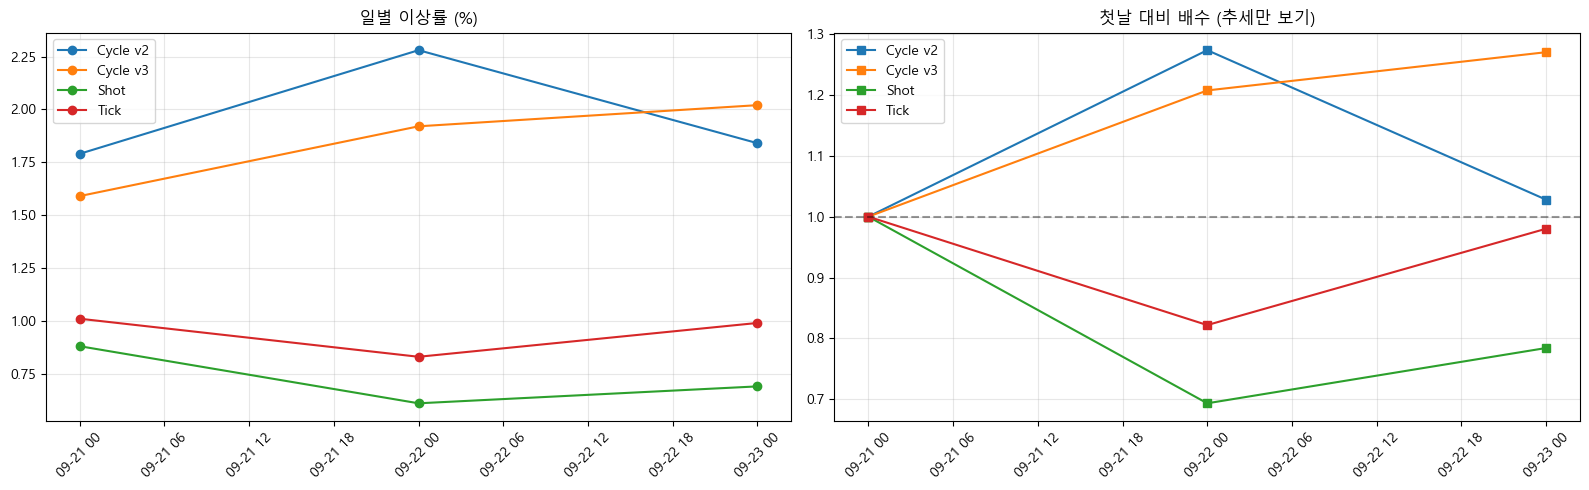

In [9]:
daily = {}
for k, df in SCORES.items():
    th = INFO[k]["threshold"]
    d = df.assign(Date=df["Time"].dt.date)
    daily[k] = d.groupby("Date")["err"].apply(lambda s: (s > th).mean() * 100)
daily = pd.DataFrame(daily).round(2)
print(daily.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for k in daily.columns:
    axes[0].plot(daily.index, daily[k], marker="o", label=k)
axes[0].set_title("일별 이상률 (%)"); axes[0].legend(); axes[0].grid(alpha=.3)
plt.setp(axes[0].get_xticklabels(), rotation=45)

norm = daily / daily.iloc[0]
for k in norm.columns:
    axes[1].plot(norm.index, norm[k], marker="s", label=k)
axes[1].axhline(1.0, color="black", ls="--", alpha=.4)
axes[1].set_title("첫날 대비 배수 (추세만 보기)"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.setp(axes[1].get_xticklabels(), rotation=45)
plt.tight_layout(); plt.show()

## 6. 검출 겹침 — 서로 대체 가능한가

단위가 다르므로 **모두 사이클 축에 매핑**해서 비교한다. 틱/사출은 자신이 속한
사이클에 붙이고, 그 사이클 안에서 하나라도 이상이면 그 사이클을 이상으로 본다.

In [10]:
base = CYC["test"].sort_values("Start_Time")
starts, ends = base["Start_Time"].to_numpy(), base["End_Time"].to_numpy()

def to_cycle_flags(times, err, th):
    t = pd.to_datetime(times).to_numpy()
    idx = np.clip(np.searchsorted(starts, t, side="right") - 1, 0, len(base) - 1)
    inside = (t >= starts[idx]) & (t <= ends[idx])
    flag = np.zeros(len(base), dtype=bool)
    hit = idx[inside & (err > th)]
    flag[hit] = True
    return flag

flags = {k: to_cycle_flags(SCORES[k]["Time"].values, SCORES[k]["err"].values, INFO[k]["threshold"])
         for k in SCORES}
print(f"기준 사이클 {len(base):,}개\n")
print("모델별로 이상이라고 본 사이클 수")
for k, f in flags.items():
    print(f"   {k:10s} {f.sum():5,d}")

print()
print("두 모델이 같은 사이클을 지목하는 비율 (자카드, %)")
names = list(flags)
J = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        u = (flags[a] | flags[b]).sum()
        J.loc[a, b] = round((flags[a] & flags[b]).sum() / u * 100, 1) if u else np.nan
print(J.to_string())

기준 사이클 9,119개

모델별로 이상이라고 본 사이클 수
   Cycle v2     181
   Cycle v3     168
   Shot          68
   Tick       1,253

두 모델이 같은 사이클을 지목하는 비율 (자카드, %)
          Cycle v2  Cycle v3   Shot   Tick
Cycle v2     100.0      35.3    1.2    4.0
Cycle v3      35.3     100.0    1.3    4.2
Shot           1.2       1.3  100.0    0.8
Tick           4.0       4.2    0.8  100.0


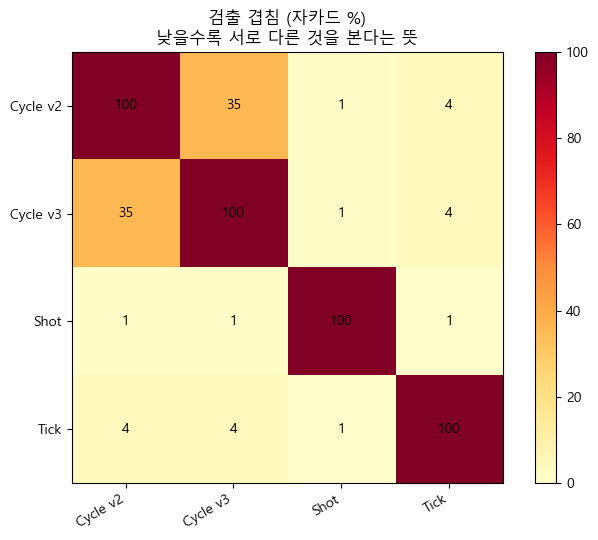

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(J.values.astype(float), cmap="YlOrRd", vmin=0, vmax=100)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{J.values[i, j]:.0f}", ha="center", va="center", fontsize=10)
ax.set_title("검출 겹침 (자카드 %)\n낮을수록 서로 다른 것을 본다는 뜻")
fig.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

## 7. 결론 정리

In [12]:
print("=" * 74)
print("라벨이 없어도 확정할 수 있는 것")
print("=" * 74)
for k in names:
    c = INFO[k]["culprits"]
    sv_like = [f for f in c.index[:5] if any(s in f for s in
               ["Phase_Transition", "SV_mean", "g_s_SV", "SV_at_Shot", "Prev_SV"])]
    if sv_like:
        share = c[sv_like].sum()
        print(f"  {k:10s} 상위 범인에 '설정값 관련' 포함 → {', '.join(sv_like)} (합 {share:.0f}%)")
    else:
        print(f"  {k:10s} 상위 범인이 모두 물리 지표")
print()
print("=" * 74)
print("현장 운용 관점 (하루당 경보량)")
print("=" * 74)
for k in names:
    print(f"  {k:10s} {INFO[k]['n_anom']/days:6.1f} 건/일")

라벨이 없어도 확정할 수 있는 것
  Cycle v2   상위 범인이 모두 물리 지표
  Cycle v3   상위 범인이 모두 물리 지표
  Shot       상위 범인이 모두 물리 지표
  Tick       상위 범인에 '설정값 관련' 포함 → Phase_Transition, g_s_SV_P1 (합 38%)

현장 운용 관점 (하루당 경보량)
  Cycle v2     61.2 건/일
  Cycle v3     56.8 건/일
  Shot         23.0 건/일
  Tick        459.4 건/일
